In [1]:
import pandas as pd
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("loan_approval_data.csv")

In [3]:
df.sample(10)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
852,853.0,13397.0,3719.0,Self-employed,33.0,Single,1.0,697.0,0.0,0.50,12742.0,12511.0,20830.0,12.0,Business,Semiurban,Not Graduate,Male,MNC,No
392,393.0,5373.0,3676.0,Salaried,35.0,Married,NaN,585.0,0.0,0.32,14887.0,20043.0,7299.0,60.0,Home,Semiurban,Graduate,Male,Private,No
739,NaN,15234.0,4445.0,Unemployed,41.0,Single,1.0,590.0,2.0,0.15,14925.0,20312.0,7608.0,24.0,Education,Urban,NaN,Male,MNC,No
713,714.0,12167.0,6570.0,Contract,41.0,Married,1.0,630.0,4.0,0.34,18700.0,32875.0,24279.0,NaN,Home,Semiurban,Graduate,Male,Private,No
834,835.0,8359.0,7426.0,Salaried,35.0,Single,2.0,565.0,1.0,NaN,7933.0,33305.0,28453.0,60.0,Education,Semiurban,NaN,Female,Government,No
10,11.0,18023.0,4033.0,Salaried,52.0,Married,2.0,688.0,1.0,0.13,18244.0,40004.0,10415.0,12.0,Education,Urban,Not Graduate,Female,MNC,Yes
118,119.0,18312.0,6609.0,Salaried,21.0,Single,0.0,768.0,4.0,0.38,7973.0,42770.0,7764.0,84.0,Home,Rural,Graduate,Male,MNC,Yes
844,845.0,12147.0,3374.0,Contract,32.0,Married,1.0,757.0,0.0,NaN,16059.0,20446.0,13262.0,60.0,Home,Semiurban,Graduate,Male,Business,Yes
205,206.0,8295.0,9155.0,Self-employed,51.0,Married,1.0,712.0,4.0,0.29,10559.0,347.0,20095.0,24.0,Personal,Rural,Graduate,NaN,MNC,Yes
777,778.0,14219.0,7227.0,Salaried,58.0,Married,3.0,590.0,4.0,0.40,1525.0,20221.0,26538.0,48.0,Home,Urban,NaN,Male,Private,No


In [4]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


# Handle Missing Values

In [5]:
categorical_cols = df.select_dtypes(include = ["object"]).columns
numerical_cols = df.select_dtypes(include = ["number"]).columns
#number include all numerical values like float and int and if we want any specific data type we can write only the particular data type.

In [6]:
#SimpleImputer to fill categorical and numerical val with particular val like mean, mode, median

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

cat_imp = SimpleImputer(strategy = "most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

# EDA

Text(0.5, 1.0, 'Is loan Approved or Not?')

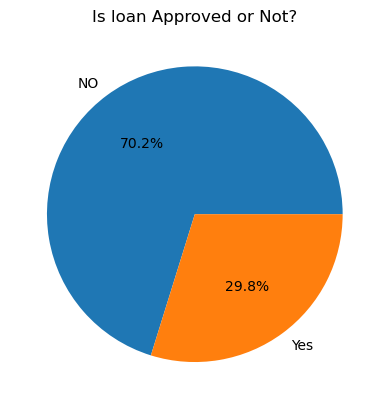

In [7]:
# Checked the distribution of target column
classes_count = df["Loan_Approved"].value_counts()

plt.pie(classes_count, labels = ["NO", "Yes"], autopct="%1.1f%%")
plt.title("Is loan Approved or Not?")

In [8]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


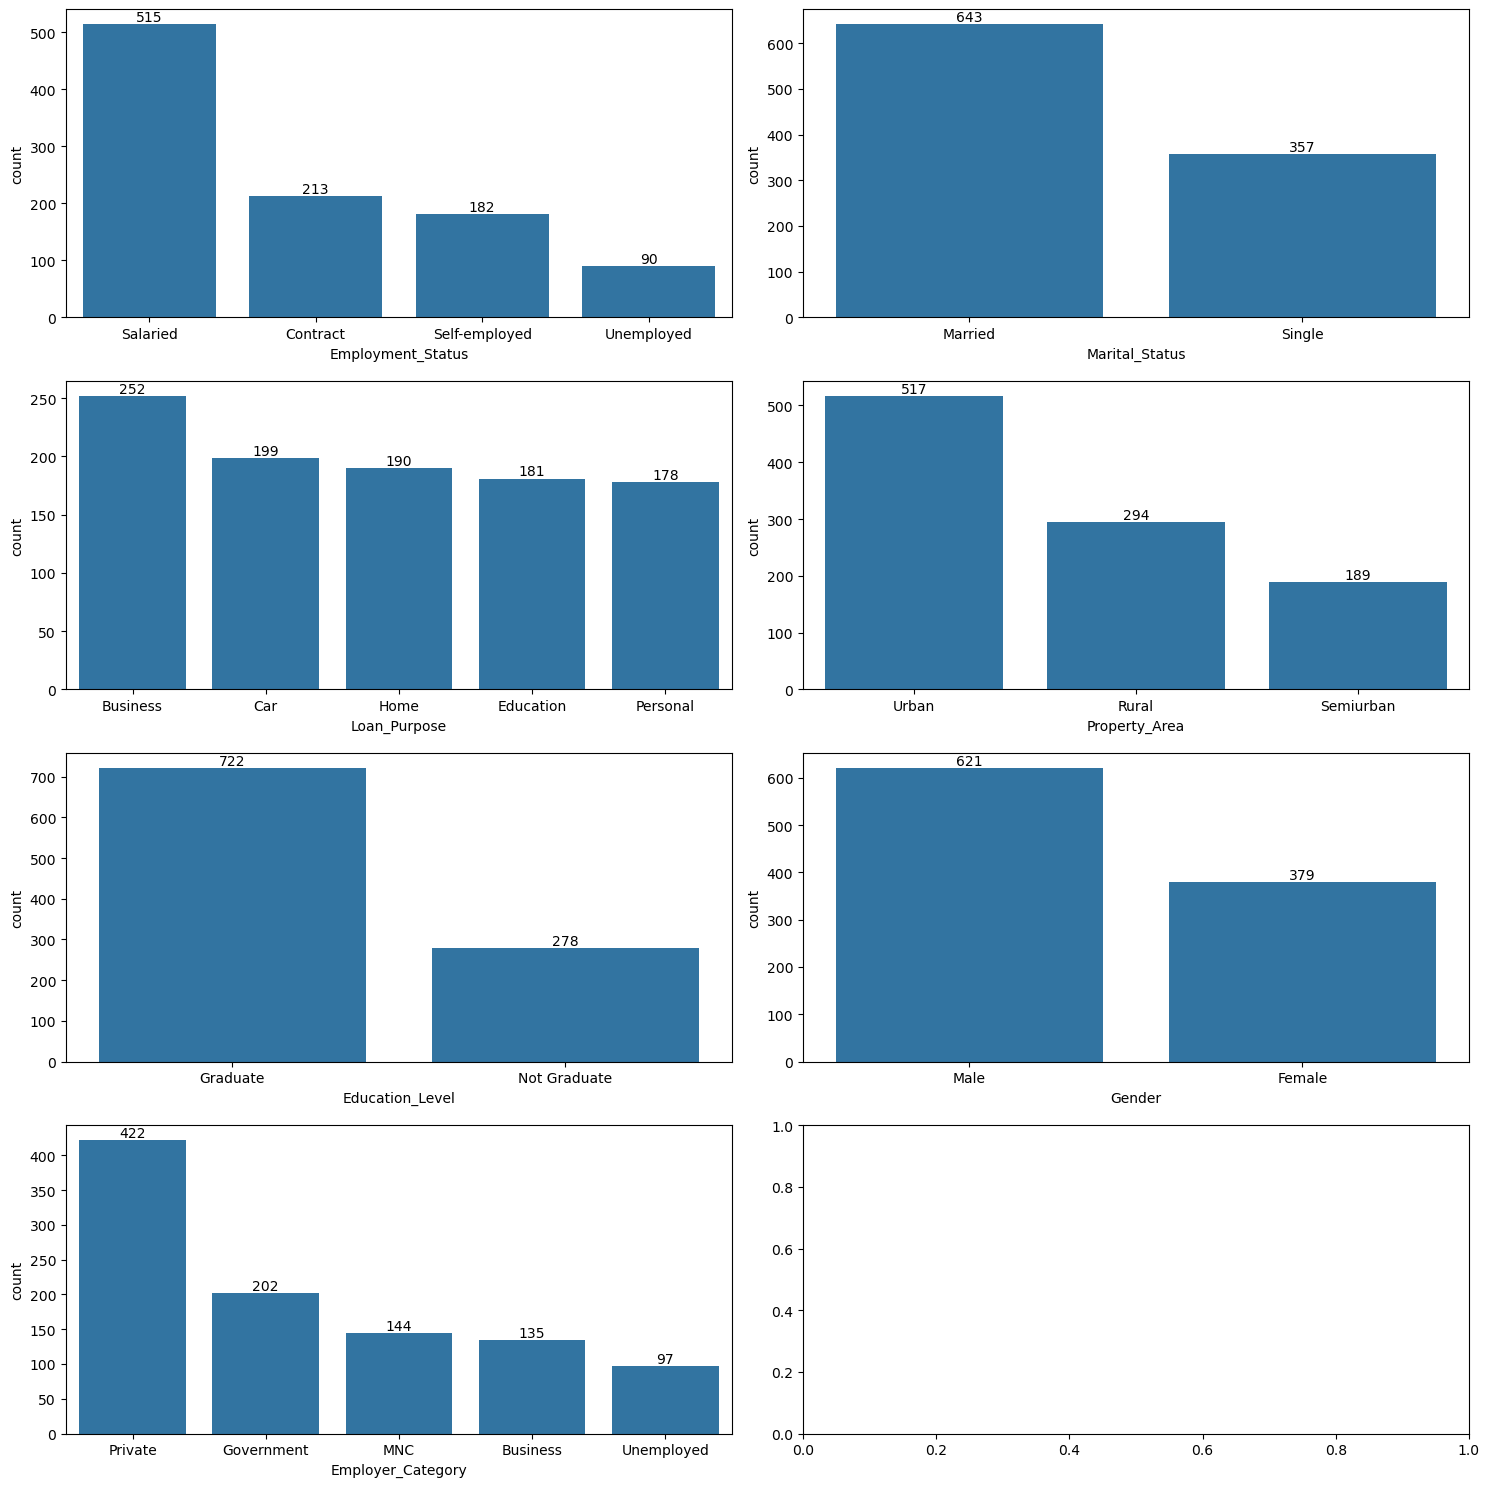

In [9]:
#distribution of feature columns
bar_feature_col = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Education_Level", "Gender", "Employer_Category"]

fig,ax = plt.subplots(4,2, figsize = (15,15))
count = 0
for i in range(4):
    for j in range(2):
        if (count < len(bar_feature_col)):
            
            feature = bar_feature_col[count]
            feaure_stat_count = df[feature].value_counts()
            axes = sns.barplot(feaure_stat_count,ax = ax[i][j])
            axes.bar_label(axes.containers[0])
            

        count = count + 1
fig.tight_layout()
# emp_stat_count = df["Loan_Purpose"].value_counts()
# ax = sns.barplot(emp_stat_count)
# ax.bar_label(ax.containers[0])

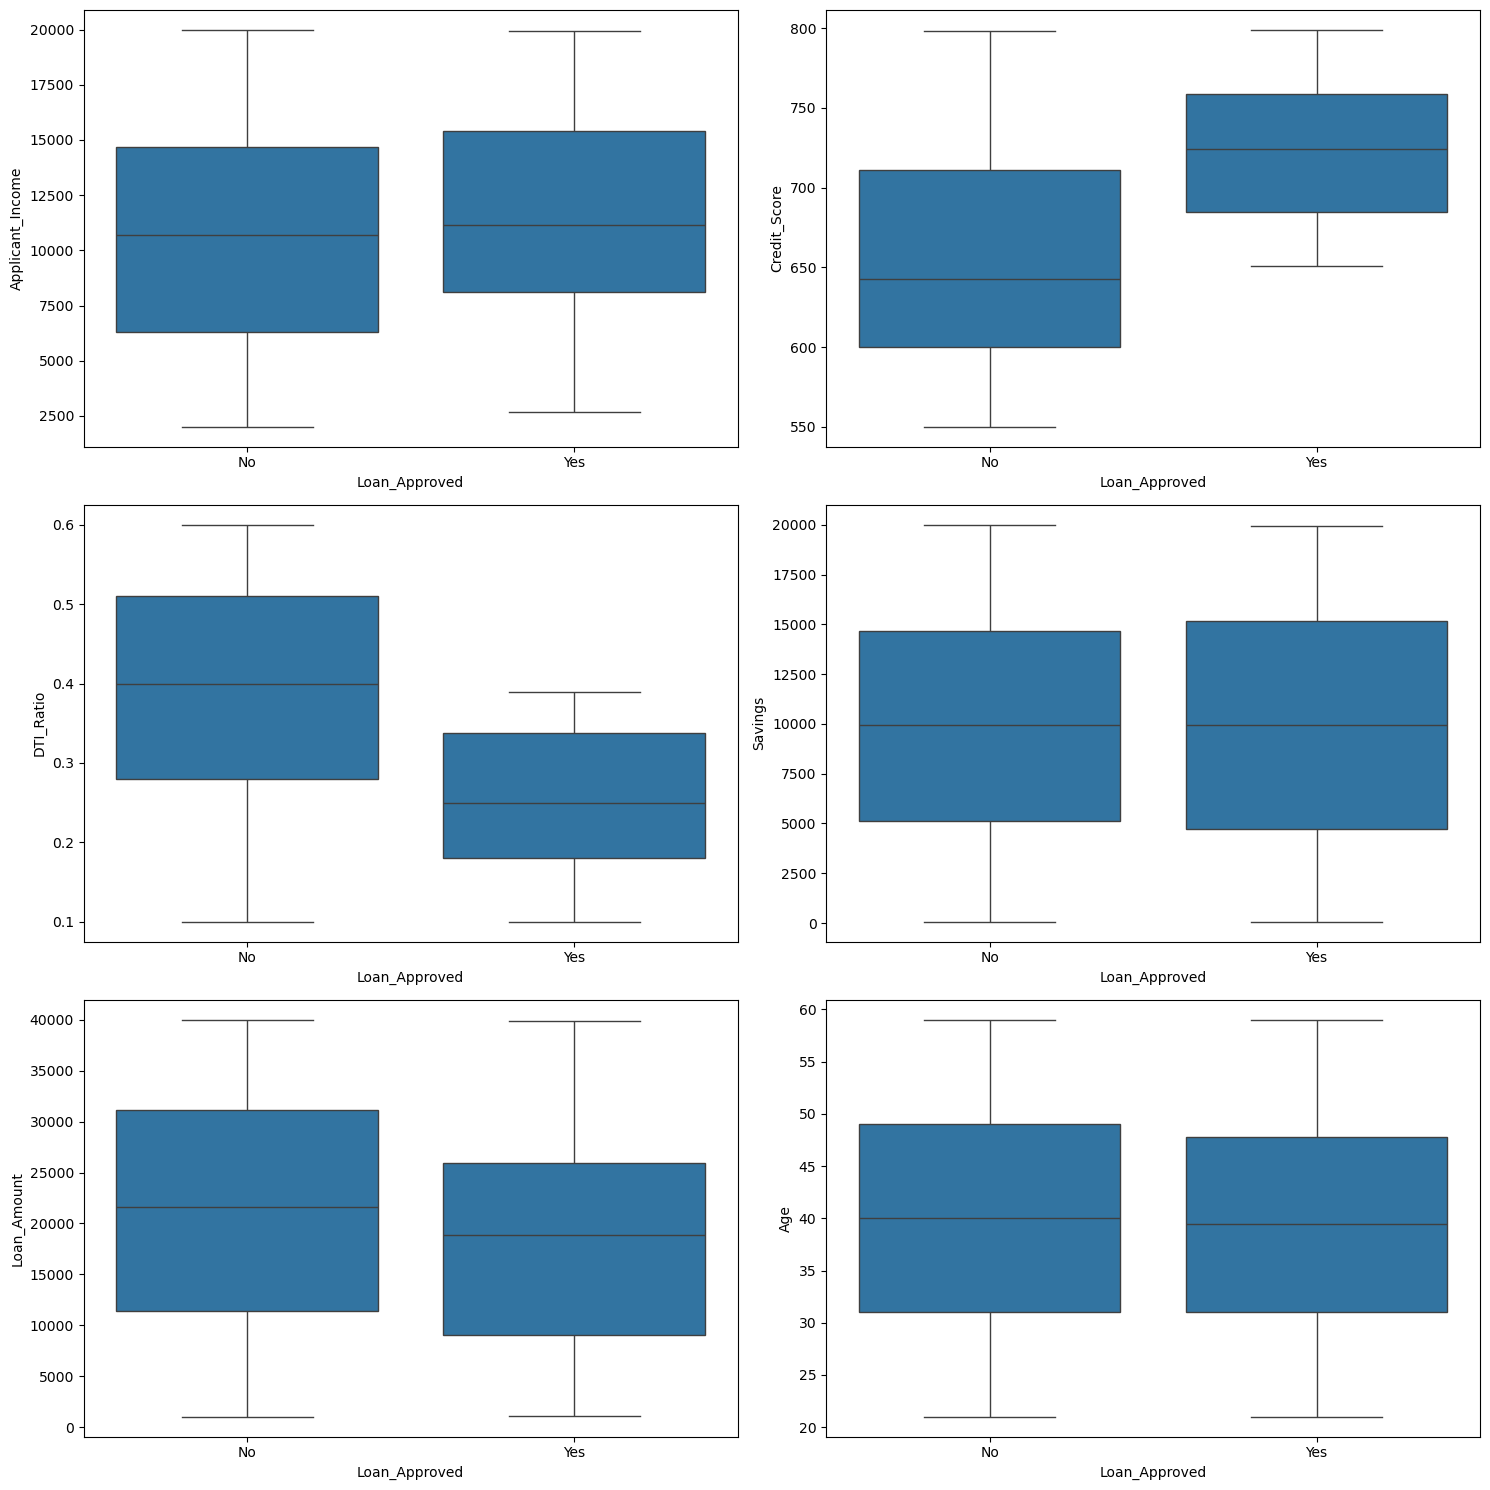

In [12]:
# outliers checking

fig, axes = plt.subplots(3,2, figsize = (15,15))
sns.boxplot(data = df, x = "Loan_Approved", y = "Applicant_Income", ax = axes[0,0])
sns.boxplot(data = df, x = "Loan_Approved", y = "Credit_Score", ax = axes[0,1])
sns.boxplot(data = df, x = "Loan_Approved", y = "DTI_Ratio", ax = axes[1,0])
sns.boxplot(data = df, x = "Loan_Approved", y = "Savings", ax = axes[1,1])
sns.boxplot(data = df, x = "Loan_Approved", y = "Loan_Amount", ax = axes[2,0])
sns.boxplot(data = df, x = "Loan_Approved", y = "Age", ax = axes[2,1])

plt.tight_layout()

In [14]:
#Drop applicant Id 
df =  df.drop("Applicant_ID", axis = 1)

In [15]:
df

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes
